# HR Employee Attrition Analysis

A simple look at the employee attrition dataset to see where attrition is higher and which variables are worth looking at.

In [2]:
# Import the libraries we need
import pandas as pd                # data tables
import numpy as np                 # numbers
import matplotlib.pyplot as plt    # charts
import seaborn as sns              # nicer charts
from scipy import stats            # statistical tests

sns.set_style("whitegrid")         # clean chart style

# Load dataset
df = pd.read_csv("HR-Employee-Attrition.csv")

## Questions

A few things I wanted to check:
- How many employees left?
- Is overtime connected with attrition?
- Is income different between employees who left and stayed?
- Is age different between the two groups?
- Which departments and job roles have higher attrition?
- Are there any data-quality issues?

## Getting familiar with the data

First, check the size of the dataset and a few rows.

In [3]:
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Observation:** The dataset contains 1,470 employee records and 35 columns, so there is enough information to compare attrition across several employee characteristics.

Check the columns and their data types.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

Some basic summary statistics.

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


For the main categorical columns, check how the values are distributed.

In [6]:
# Categorical columns
text_columns = ["Attrition", "BusinessTravel", "Department", "Gender", "MaritalStatus", "OverTime", "JobRole"]

for col in text_columns:
    print(col)
    print(df[col].value_counts())
    print()

Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

OverTime
OverTime
No     1054
Yes     416
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64



There are 1,470 employees and 35 columns. The dataset contains both numeric and categorical columns, with no missing values in the main fields checked here.

## Looking at attrition

### Attrition overview

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


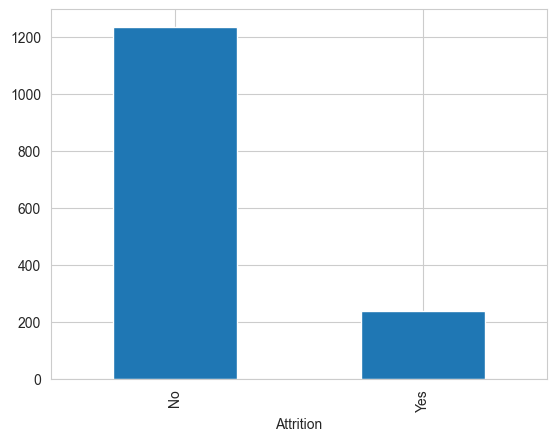

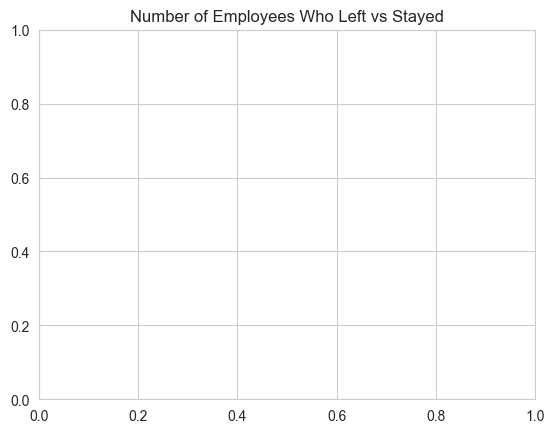

In [7]:
# Counts and percentages
print(df["Attrition"].value_counts())


print()
print(df["Attrition"].value_counts(normalize=True) * 100)

df["Attrition"].value_counts().plot.bar()

plt.show()
plt.title("Number of Employees Who Left vs Stayed")
plt.show()

**Observation:** The target is imbalanced: about 83.9% of employees stayed and 16.1% left. This is important to keep in mind if the dataset is later used for a prediction model.

### Distribution of a few numeric variables

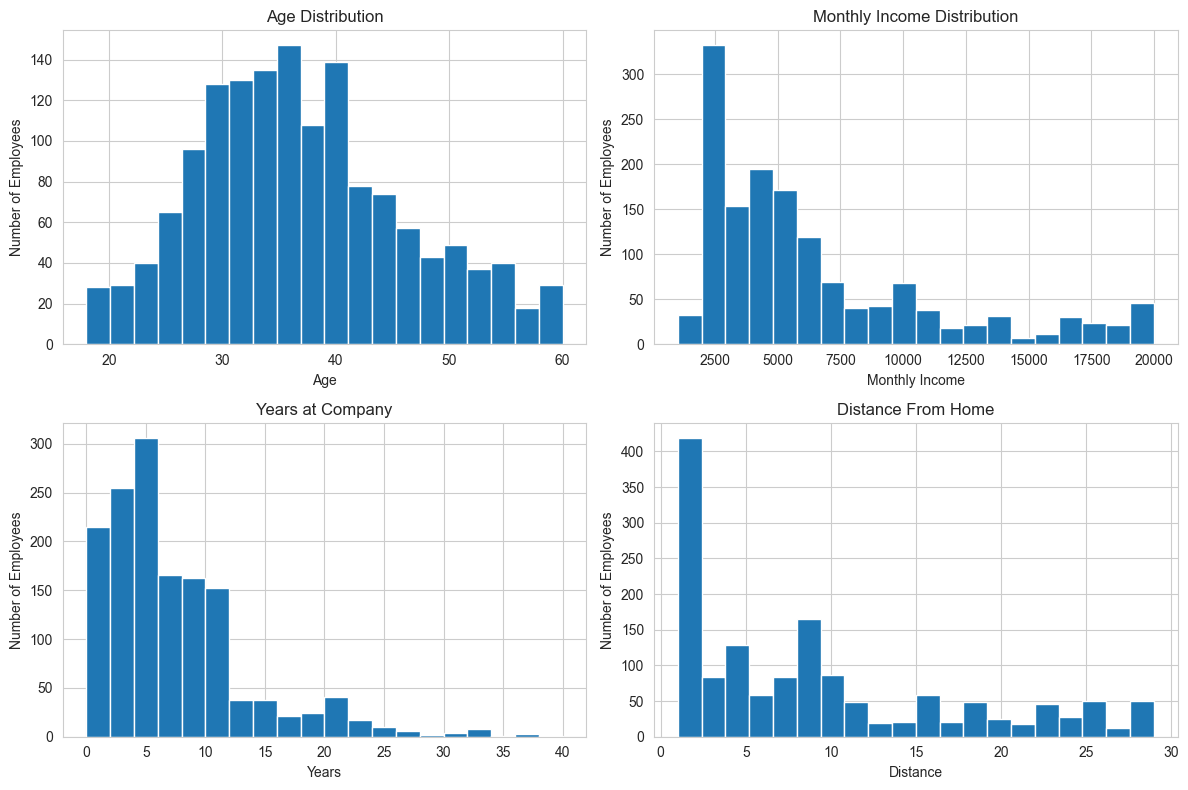

In [8]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("HR-Employee-Attrition.csv")

# Check the distribution of important columns

plt.figure(figsize=(12, 8))

# Age
plt.subplot(2, 2, 1)
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

# Monthly Income
plt.subplot(2, 2, 2)
plt.hist(df["MonthlyIncome"], bins=20)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

# Years at Company
plt.subplot(2, 2, 3)
plt.hist(df["YearsAtCompany"], bins=20)
plt.title("Years at Company")
plt.xlabel("Years")
plt.ylabel("Number of Employees")

# Distance From Home
plt.subplot(2, 2, 4)
plt.hist(df["DistanceFromHome"], bins=20)
plt.title("Distance From Home")
plt.xlabel("Distance")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()



### Overtime

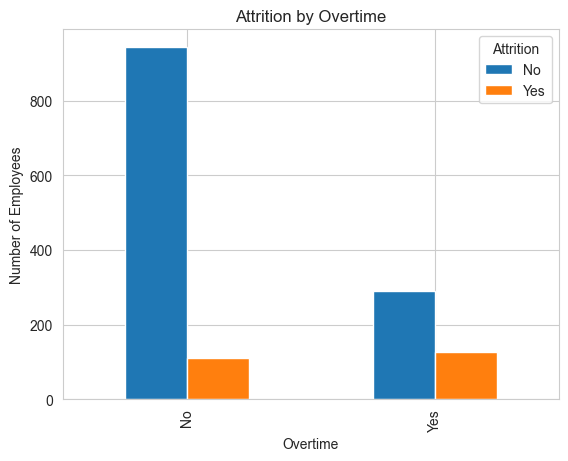

In [9]:
df.groupby(["OverTime", "Attrition"]).size().unstack().plot(kind="bar")

plt.title("Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.show()


**Observation:** Employees who work overtime show a noticeably higher attrition rate than employees who do not. This suggests overtime is one of the factors worth looking at more closely when studying employee turnover.

### Income and age

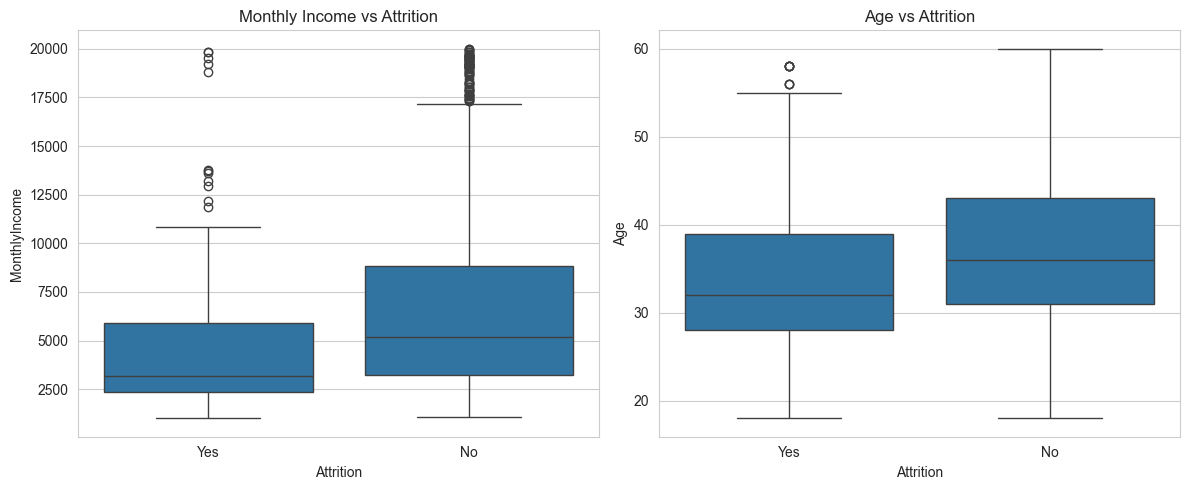

           MonthlyIncome   Age  YearsAtCompany
Attrition                                     
No                6832.7  37.6             7.4
Yes               4787.1  33.6             5.1


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", ax=axes[0])
axes[0].set_title("Monthly Income vs Attrition")

sns.boxplot(data=df, x="Attrition", y="Age", ax=axes[1])
axes[1].set_title("Age vs Attrition")

plt.tight_layout()
plt.show()

# Group averages
print(df.groupby("Attrition")[["MonthlyIncome", "Age", "YearsAtCompany"]].mean().round(1))

### Department and job role

Department
Human Resources           19.0
Research & Development    13.8
Sales                     20.6
Name: Attrition, dtype: float64


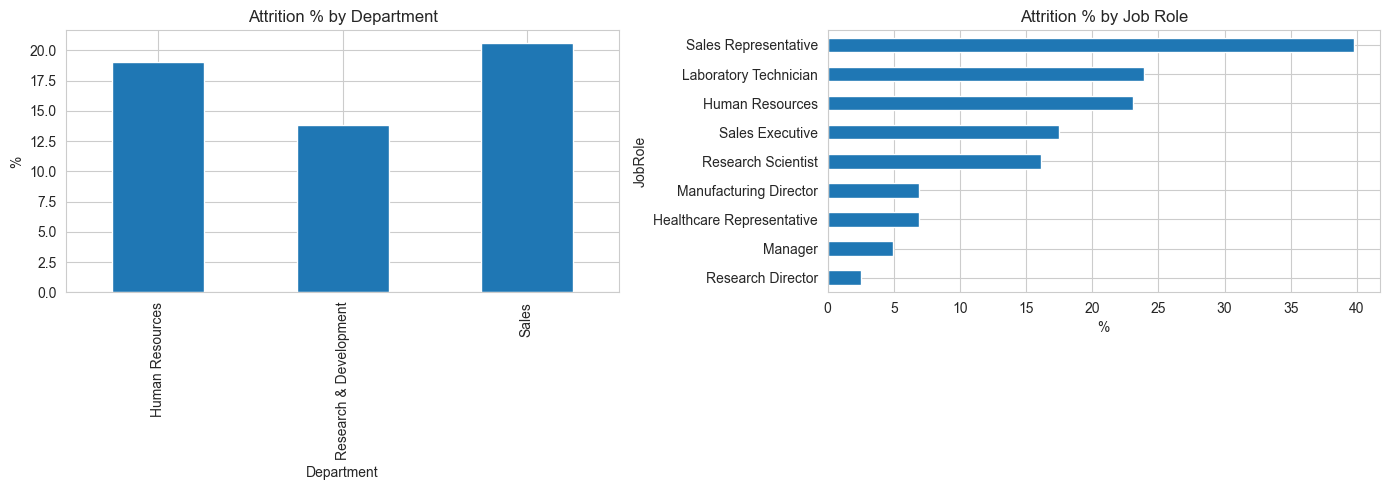

In [11]:
# Attrition rate
dept_rate = df.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
role_rate = df.groupby("JobRole")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values()

print(dept_rate.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_rate.plot(kind="bar", ax=axes[0])
axes[0].set_title("Attrition % by Department")
axes[0].set_ylabel("%")

role_rate.plot(kind="barh", ax=axes[1])
axes[1].set_title("Attrition % by Job Role")
axes[1].set_xlabel("%")

plt.tight_layout()
plt.show()

### Correlations

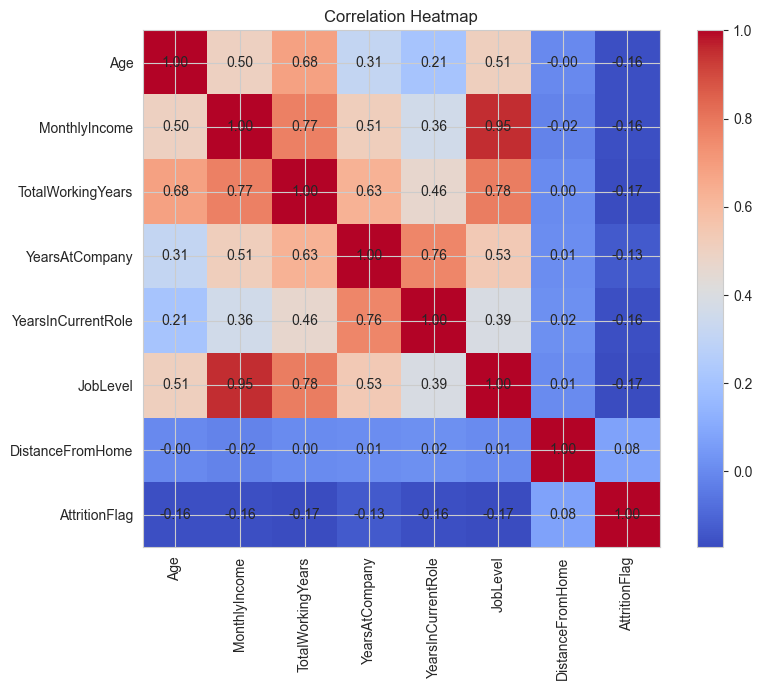

In [12]:
# Convert Attrition into numbers
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Select columns for correlation
cols = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "JobLevel",
    "DistanceFromHome",
    "AttritionFlag"
]

# Calculate correlation
corr = df[cols].corr()

# Create heatmap
plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

# Add correlation values
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()




### Checking income outliers

Number of outliers in MonthlyIncome: 114
Upper limit: 16581.0


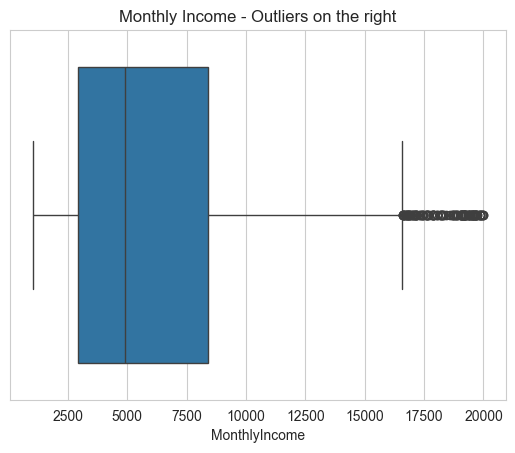

In [13]:
# IQR outlier check
Q1 = df["MonthlyIncome"].quantile(0.25)
Q3 = df["MonthlyIncome"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["MonthlyIncome"] < lower) | (df["MonthlyIncome"] > upper)]
print("Number of outliers in MonthlyIncome:", len(outliers))
print("Upper limit:", upper)

sns.boxplot(x=df["MonthlyIncome"])
plt.title("Monthly Income - Outliers on the right")
plt.show()

A few things stand out from these checks:
- 16.1% of employees in the dataset left.
- Attrition is higher among employees who work overtime.
- Employees who left have lower average income and age than employees who stayed.
- Monthly income has some high-value outliers.

## Statistical checks

The charts show differences, but statistical tests help check whether those differences are likely to be meaningful.

### Overtime and attrition

Both variables are categorical, so a chi-square test is used here.

In [14]:
table = pd.crosstab(df["OverTime"], df["Attrition"])
print(table)

chi2, p_value, dof, expected = stats.chi2_contingency(table)
print("\nChi-square:", round(chi2, 2))
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 -> Overtime IS related to attrition.")
else:
    print("Result: Fail to reject H0 -> No evidence of a relationship.")

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127

Chi-square: 87.56
p-value: 8.15842372153832e-21
Result: Reject H0 -> Overtime IS related to attrition.


### Monthly income and attrition

Income is compared between employees who left and those who stayed. Because income is right-skewed, I also used a Mann-Whitney test as a second check.

In [15]:
left = df[df["Attrition"] == "Yes"]["MonthlyIncome"]
stayed = df[df["Attrition"] == "No"]["MonthlyIncome"]

print("Average income - Left:  ", round(left.mean()))
print("Average income - Stayed:", round(stayed.mean()))
print("Skewness of income (0 = symmetric):", round(df["MonthlyIncome"].skew(), 2))

# t-test
t_stat, p_ttest = stats.ttest_ind(left, stayed)
print("\nt-test p-value:", p_ttest)

# Mann-Whitney U test
u_stat, p_mw = stats.mannwhitneyu(left, stayed)
print("Mann-Whitney p-value:", p_mw)

if p_ttest < 0.05 and p_mw < 0.05:
    print("Result: Reject H0 -> Income is significantly different (both tests agree).")
else:
    print("Result: Fail to reject H0.")

Average income - Left:   4787
Average income - Stayed: 6833
Skewness of income (0 = symmetric): 1.37

t-test p-value: 7.147363985353823e-10
Mann-Whitney p-value: 2.950830917288873e-14
Result: Reject H0 -> Income is significantly different (both tests agree).


### Age and attrition

Compare the average age of employees who left with those who stayed.

In [16]:
left_age = df[df["Attrition"] == "Yes"]["Age"]
stayed_age = df[df["Attrition"] == "No"]["Age"]

print("Average age - Left:  ", round(left_age.mean(), 1))
print("Average age - Stayed:", round(stayed_age.mean(), 1))

t_stat, p_value = stats.ttest_ind(left_age, stayed_age)
print("\np-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 -> Age is significantly different.")
else:
    print("Result: Fail to reject H0.")

Average age - Left:   33.6
Average age - Stayed: 37.6

p-value: 8.356308021103588e-10
Result: Reject H0 -> Age is significantly different.


### Experience and income

Check whether total working years and monthly income move together.

Correlation: 0.77
p-value: 2.729347615691242e-292


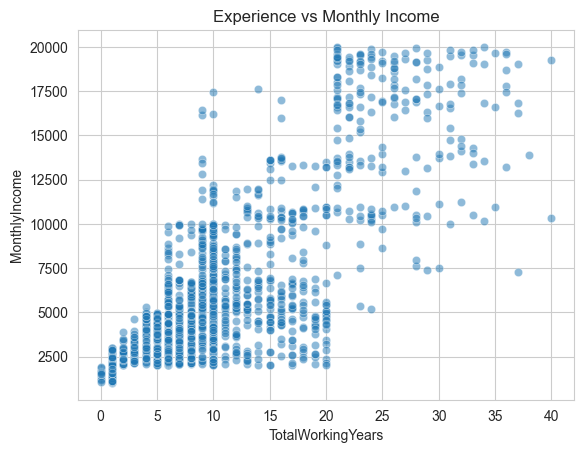

In [17]:
corr, p_value = stats.pearsonr(df["TotalWorkingYears"], df["MonthlyIncome"])
print("Correlation:", round(corr, 2))
print("p-value:", p_value)

sns.scatterplot(data=df, x="TotalWorkingYears", y="MonthlyIncome", alpha=0.5)
plt.title("Experience vs Monthly Income")
plt.show()

**Observation:** Total working years and monthly income have a strong positive relationship in this dataset. In general, employees with more total working experience tend to have higher monthly income.

## Data-quality checks

### Missing values and duplicates

In [18]:
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


**Observation:** There are no missing values and no duplicate rows in the dataset, so no missing-value treatment or duplicate removal is needed at this stage.

### Columns with no variation

In [19]:
# Check constant columns
unique_counts = df.nunique()
print(unique_counts[unique_counts == 1])

# EmployeeNumber is an ID
print("\nEmployeeNumber unique values:", df["EmployeeNumber"].nunique(), "out of", len(df))

EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64

EmployeeNumber unique values: 1470 out of 1470


**Observation:** `EmployeeCount`, `Over18`, and `StandardHours` have only one unique value. These columns do not help distinguish employees. `EmployeeNumber` is also just an identifier because every employee has a different number.

### Attrition balance

In [20]:
# Class proportions
print(df["Attrition"].value_counts(normalize=True).round(3) * 100)

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


### Skewness

In [21]:
# Skewness
num_cols = ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "YearsSinceLastPromotion"]
print(df[num_cols].skew().round(2))

Age                        0.41
MonthlyIncome              1.37
TotalWorkingYears          1.12
YearsAtCompany             1.76
YearsSinceLastPromotion    1.98
dtype: float64


**Observation:** Monthly income, total working years, years at company, and years since last promotion are positively skewed. This means a smaller number of larger values are pulling these distributions to the right.

### Highly related columns

In [22]:
# Correlations
print("Income vs JobLevel correlation:", round(df["MonthlyIncome"].corr(df["JobLevel"]), 2))
print("Income vs TotalWorkingYears correlation:", round(df["MonthlyIncome"].corr(df["TotalWorkingYears"]), 2))

Income vs JobLevel correlation: 0.95
Income vs TotalWorkingYears correlation: 0.77


**Observation:** Monthly income and JobLevel have a very strong correlation of 0.95. Monthly income is also strongly related to total working years (0.77), so these variables contain overlapping information.

# 5. Data Visualization

## Overall Employee Attrition

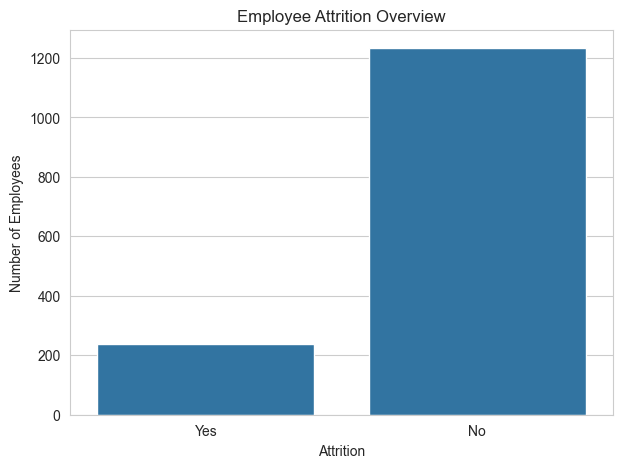

In [23]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Overview")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

## Overtime vs Attrition

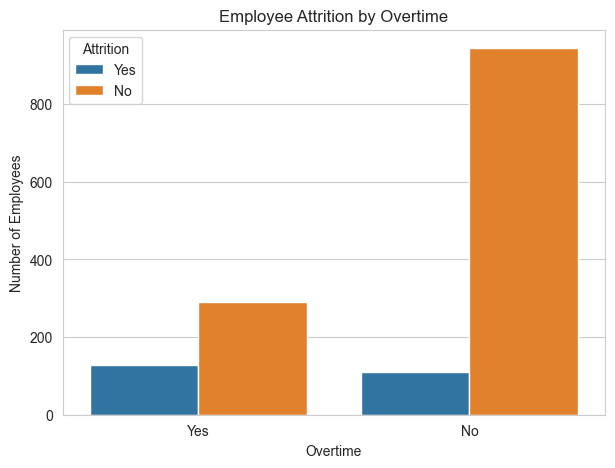

In [24]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("Employee Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.show()

## Department vs Attrition

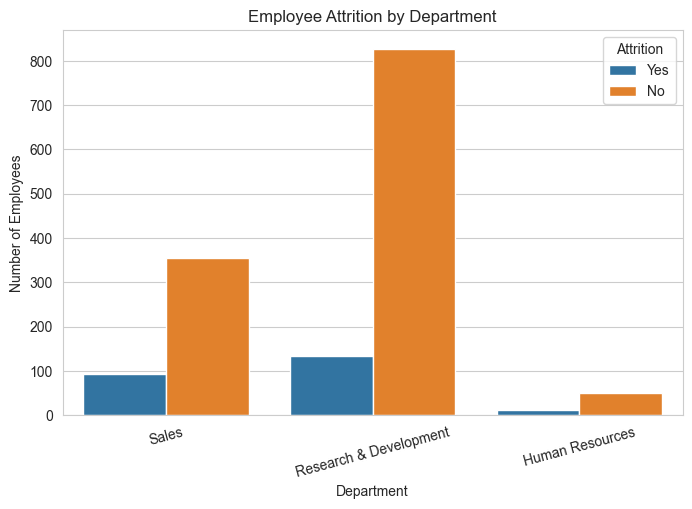

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Department", hue="Attrition")
plt.title("Employee Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=15)
plt.show()

## Job Role vs Attrition

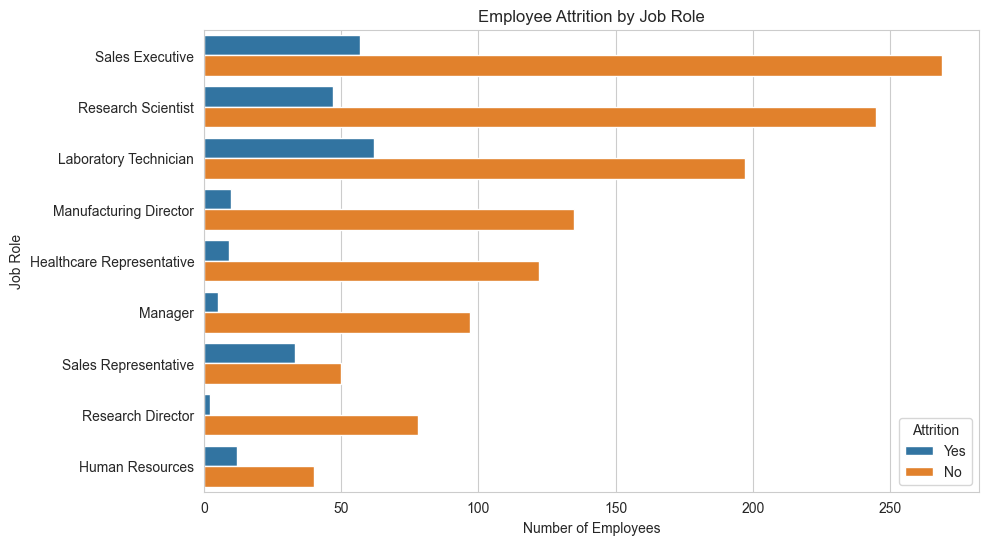

In [26]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y="JobRole", hue="Attrition")
plt.title("Employee Attrition by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.show()

## Monthly Income vs Attrition

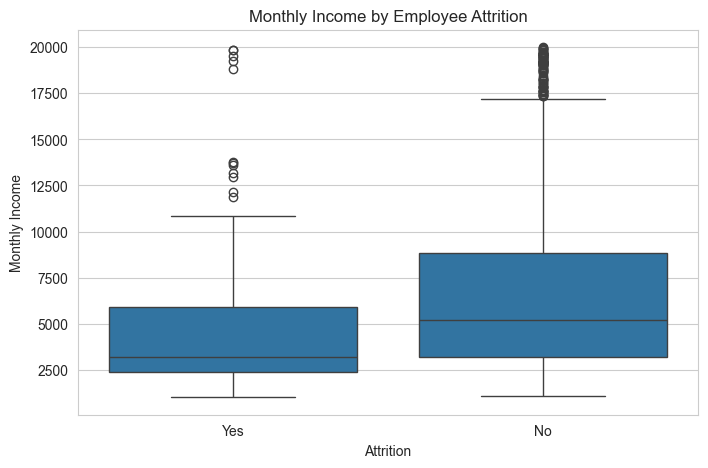

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

# Final HR Employee Attrition Dashboard

This dashboard brings together the most important findings from the analysis into a single visual summary. It focuses on overall attrition, overtime, departments, job roles, and monthly income to make the main patterns easier to compare and understand.

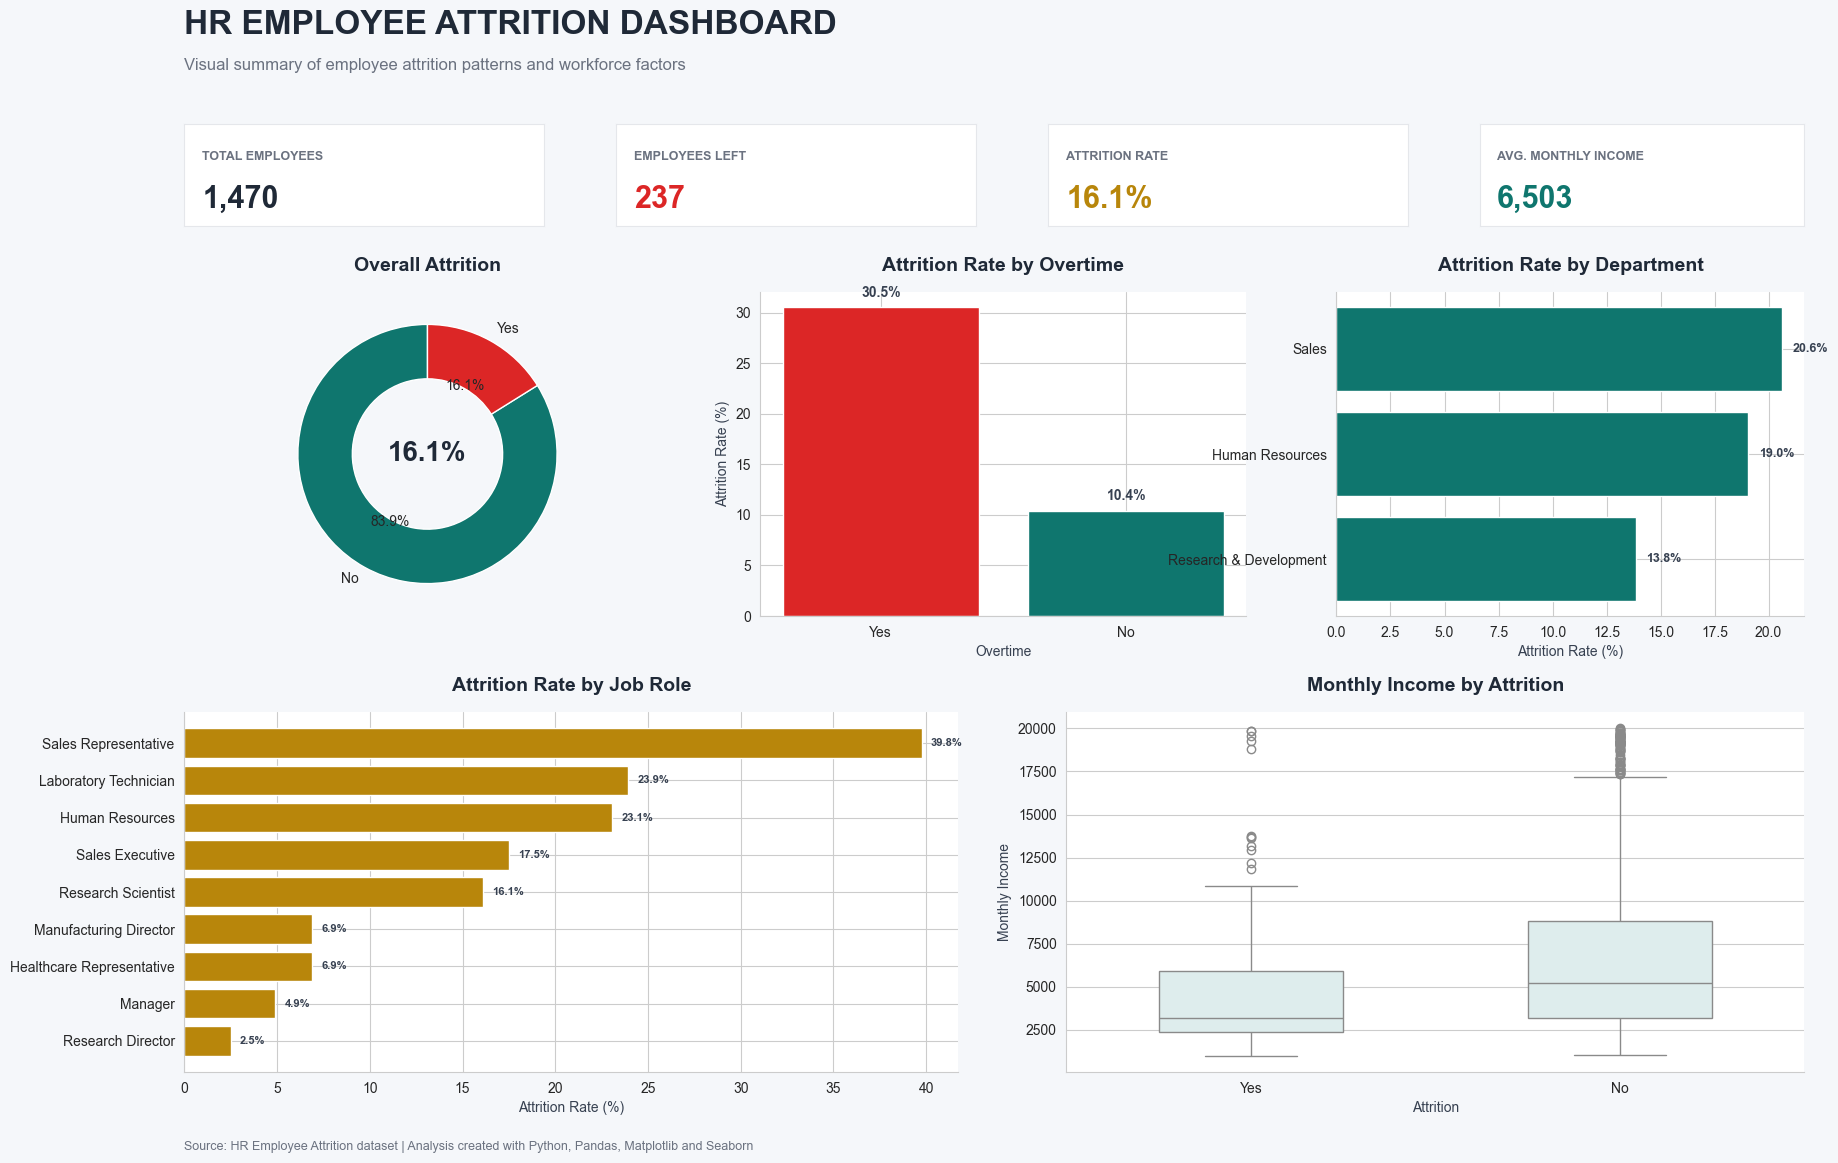

In [28]:
# ============================================================
# FINAL HR EMPLOYEE ATTRITION DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure AttritionFlag exists
if "AttritionFlag" not in df.columns:
    df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

# -----------------------------
# Prepare dashboard data
# -----------------------------

total_employees = len(df)
employees_left = (df["Attrition"] == "Yes").sum()
attrition_rate = employees_left / total_employees * 100
avg_income = df["MonthlyIncome"].mean()

# Overtime attrition rate
overtime_rate = (
    df.groupby("OverTime")["AttritionFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Department attrition rate
department_rate = (
    df.groupby("Department")["AttritionFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

# Job role attrition rate
jobrole_rate = (
    df.groupby("JobRole")["AttritionFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

# -----------------------------
# Professional color palette
# -----------------------------

navy = "#1F2937"
teal = "#0F766E"
red = "#DC2626"
gold = "#B8860B"
light_bg = "#F5F7FA"
dark_gray = "#374151"
gray = "#6B7280"

# -----------------------------
# Create dashboard
# -----------------------------

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(light_bg)

# Main title
fig.text(
    0.05, 0.965,
    "HR EMPLOYEE ATTRITION DASHBOARD",
    fontsize=24,
    fontweight="bold",
    color=navy
)

fig.text(
    0.05, 0.935,
    "Visual summary of employee attrition patterns and workforce factors",
    fontsize=12,
    color=gray
)

# ============================================================
# KPI CARDS
# ============================================================

kpi_positions = [
    (0.05, 0.805, 0.20, 0.085),
    (0.29, 0.805, 0.20, 0.085),
    (0.53, 0.805, 0.20, 0.085),
    (0.77, 0.805, 0.18, 0.085)
]

kpi_values = [
    f"{total_employees:,}",
    f"{employees_left:,}",
    f"{attrition_rate:.1f}%",
    f"{avg_income:,.0f}"
]

kpi_titles = [
    "TOTAL EMPLOYEES",
    "EMPLOYEES LEFT",
    "ATTRITION RATE",
    "AVG. MONTHLY INCOME"
]

kpi_colors = [
    navy,
    red,
    gold,
    teal
]

for position, value, title, color in zip(
    kpi_positions, kpi_values, kpi_titles, kpi_colors
):
    ax = fig.add_axes(position)
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_edgecolor("#E5E7EB")

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.05, 0.65,
        title,
        fontsize=9,
        fontweight="bold",
        color=gray,
        transform=ax.transAxes
    )

    ax.text(
        0.05, 0.18,
        value,
        fontsize=22,
        fontweight="bold",
        color=color,
        transform=ax.transAxes
    )

# ============================================================
# 1. ATTRITION OVERVIEW
# ============================================================

ax1 = fig.add_axes([0.05, 0.48, 0.27, 0.27])

attrition_counts = df["Attrition"].value_counts()

wedges, texts, autotexts = ax1.pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[teal, red],
    wedgeprops=dict(width=0.42, edgecolor="white"),
    textprops=dict(fontsize=10)
)

ax1.text(
    0, 0,
    f"{attrition_rate:.1f}%",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color=navy
)

ax1.set_title(
    "Overall Attrition",
    fontsize=14,
    fontweight="bold",
    color=navy,
    pad=15
)

# ============================================================
# 2. OVERTIME ATTRITION RATE
# ============================================================

ax2 = fig.add_axes([0.37, 0.48, 0.27, 0.27])

bars = ax2.bar(
    overtime_rate.index,
    overtime_rate.values,
    color=[red if x == overtime_rate.max() else teal
           for x in overtime_rate.values]
)

ax2.set_title(
    "Attrition Rate by Overtime",
    fontsize=14,
    fontweight="bold",
    color=navy,
    pad=15
)

ax2.set_xlabel("Overtime", color=dark_gray)
ax2.set_ylabel("Attrition Rate (%)", color=dark_gray)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=dark_gray
    )

# ============================================================
# 3. DEPARTMENT ATTRITION
# ============================================================

ax3 = fig.add_axes([0.69, 0.48, 0.26, 0.27])

bars = ax3.barh(
    department_rate.index,
    department_rate.values,
    color=teal
)

ax3.set_title(
    "Attrition Rate by Department",
    fontsize=14,
    fontweight="bold",
    color=navy,
    pad=15
)

ax3.set_xlabel("Attrition Rate (%)", color=dark_gray)

ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax3.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=dark_gray
    )

# ============================================================
# 4. JOB ROLE ATTRITION
# ============================================================

ax4 = fig.add_axes([0.05, 0.10, 0.43, 0.30])

bars = ax4.barh(
    jobrole_rate.index,
    jobrole_rate.values,
    color=gold
)

ax4.set_title(
    "Attrition Rate by Job Role",
    fontsize=14,
    fontweight="bold",
    color=navy,
    pad=15
)

ax4.set_xlabel("Attrition Rate (%)", color=dark_gray)

ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax4.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=8,
        fontweight="bold",
        color=dark_gray
    )

# ============================================================
# 5. MONTHLY INCOME VS ATTRITION
# ============================================================

ax5 = fig.add_axes([0.54, 0.10, 0.41, 0.30])

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    ax=ax5,
    color="#DCEFEF",
    width=0.5
)

ax5.set_title(
    "Monthly Income by Attrition",
    fontsize=14,
    fontweight="bold",
    color=navy,
    pad=15
)

ax5.set_xlabel("Attrition", color=dark_gray)
ax5.set_ylabel("Monthly Income", color=dark_gray)

ax5.spines["top"].set_visible(False)
ax5.spines["right"].set_visible(False)

# -----------------------------
# Dashboard footer
# -----------------------------

fig.text(
    0.05, 0.035,
    "Source: HR Employee Attrition dataset | Analysis created with Python, Pandas, Matplotlib and Seaborn",
    fontsize=9,
    color=gray
)

plt.show()

### Data-quality summary

- No missing values were found.
- No duplicate rows were found.
- `EmployeeCount`, `Over18`, and `StandardHours` contain only one value, so they would not add useful information to a model.
- `EmployeeNumber` is an ID rather than a useful feature.
- Attrition is imbalanced: 16.1% left and 83.9% stayed.
- Monthly income and some experience-related variables are right-skewed.
- `MonthlyIncome` and `JobLevel` are very strongly correlated.

## Data Story

Employee attrition is an important workforce issue because losing employees can affect team stability, workload, and organizational resources. This analysis uses employee-level data to explore where attrition is more common and which characteristics are associated with employees leaving the company.

The analysis begins with the overall attrition level. Most employees in the dataset stayed with the company, while a smaller proportion left. This imbalance is important because the employees who leave represent a smaller but important group that needs closer investigation.

Work conditions provide another important perspective. The overtime analysis shows a noticeable difference in attrition between employees who work overtime and those who do not. This makes workload and overtime an important area for further HR investigation.

Attrition also varies across departments and job roles. Comparing these groups helps identify areas where employee turnover is relatively higher and where retention efforts may require closer attention.

Income and employee characteristics provide additional context. Employees who left show different income and age patterns compared with employees who stayed. The analysis also shows a strong relationship between monthly income and job level, as well as between income and total working experience.

Overall, the visualizations turn the raw employee data into a clearer picture of attrition patterns. Rather than treating all employees as one group, the analysis highlights differences across working conditions, departments, job roles, income, and employee characteristics.

## Key Insights

1. **Overall attrition:**  
   16.1% of employees in the dataset left the company, while the majority remained.

2. **Overtime:**  
   Employees who work overtime show a noticeably higher attrition rate than employees who do not work overtime.

3. **Departments:**  
   Attrition rates are not identical across departments, showing that employee turnover varies between different areas of the organization.

4. **Job roles:**  
   Attrition also differs across job roles, making role-level analysis useful when investigating employee retention.

5. **Income:**  
   Employees who left generally show different monthly income patterns compared with employees who stayed.

6. **Experience and income:**  
   Total working experience and monthly income have a strong positive relationship in the dataset.

7. **Data quality:**  
   The dataset contains no missing values or duplicate rows, while several constant columns provide little analytical value.

## Recommendations

Based on the patterns identified in the analysis, the following areas can be considered for further HR investigation:

### 1. Monitor overtime and workload
Employees working overtime show higher attrition. HR teams can monitor overtime patterns and review workload distribution to better understand whether workload is associated with employee turnover.

### 2. Investigate high-attrition job roles
Job roles with relatively higher attrition rates can be examined more closely to understand differences in workload, career progression, compensation, and employee experience.

### 3. Review department-level retention patterns
Since attrition varies between departments, HR teams can compare working conditions and employee experiences across departments to identify areas that may require additional attention.

### 4. Consider compensation and career progression
Income differs between employees who stayed and those who left. Compensation, job level, promotion opportunities, and career progression can therefore be considered when investigating retention.

### 5. Combine multiple employee factors
Attrition should not be investigated using one variable alone. Overtime, income, age, experience, job role, department, and employee satisfaction can be considered together to obtain a broader understanding of employee turnover.
   

## Conclusion

This project transformed the HR Employee Attrition dataset into a visual analysis of employee turnover patterns.

Using Python, Pandas, Matplotlib, Seaborn, and statistical analysis, the project examined overall attrition, overtime, departments, job roles, age, monthly income, experience, and other employee characteristics.

The final dashboard summarizes the most important findings in a single visual view. The analysis shows that attrition is not evenly distributed across employee groups and highlights overtime, job roles, departments, income, and employee characteristics as useful areas for further investigation.

Overall, the project demonstrates how data visualization can transform raw employee data into clear insights that support data-informed HR decision-making.